EXTRACCIÓN

In [ ]:
# Aqui importo la libreria de pandas
import pandas as pd

# En esta linea creo una variable que llevara la ruta, pero desde colab al cargarlo en archivos solo necesita el nombre.
file_path = 'candidates.csv'

# Con este try se intenta primero cargar el archivo suopniendo que esta separado por punto y coma, en caso que no lo este (como en nuestro archivo) carga el csv separado por comas.
try:
    # Cargar el CSV en un DataFrame llamado 'df_raw' (crudo)
    df_raw = pd.read_csv(file_path, sep=';')

    # Si detecta que cargó todo en una sola columna rara, significa que era con coma (Como dije arriba)
    if len(df_raw.columns) == 1:
        df_raw = pd.read_csv(file_path, sep=',')

    print("¡Archivo melo caramelo cargado!")

    # Imprimimos la forma (filas, columnas) para confirmar los 50mil registros
    print(f"Total de filas y columnas: {df_raw.shape}")
    print("-" * 40)

    #Una exepcion en caso que la ruta este mal o el archivo no este cargado.
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{file_path}'. Asegúrate de haberlo subido al panel izquierdo de Colab.")

# Mostramos las primeras 5 filas para verificar que las columnas estén bien separadas
df_raw.head()

¡Archivo melo caramelo cargado!
Total de filas y columnas: (50000, 10)
----------------------------------------


,First Name,Last Name,Email,Country,Application Date,Yoe,Seniority,Technology,Code Challenge Score,Technical Interview
0,Danielle,Levy,ashleysellers@gmail.com,UK,2024-11-23,6.0,Manager,Mulesoft,0,0.0
1,Angel,Ortega,gary31@yahoo.com,USA,2025-03-21,19.0,NaN,Mulesoft,9,6.0
2,Joshua,Lopez,austingarcia@hotmail.com,Ecuador,2024-10-12,14.0,NaN,Mulesoft,2,5.0
3,Jeffrey,Powers,courtney32@gmail.com,Colombia,2024-10-29,10.0,Lead,Java Backend,3,NaN
4,Jill,Robinson,stokessuzanne@gmail.com,Australia,2022-04-05,7.0,Junior,QA Manual,3,3.0


TRANSFORMACION

In [ ]:
# Hago una copia para trabajar seguros
df_cleaned = df_raw.copy()

#CONVERSIÓN DE FECHAS
df_cleaned['Application Date'] = pd.to_datetime(df_cleaned['Application Date'])

#MANEJO DE NULOS, OUTLIERS E INCONSISTENCIAS
df_cleaned['Technical Interview'] = df_cleaned['Technical Interview'].fillna(0)
df_cleaned.loc[df_cleaned['Code Challenge Score'] > 10, 'Code Challenge Score'] = df_cleaned['Code Challenge Score'] / 10
df_cleaned['Code Challenge Score'] = df_cleaned['Code Challenge Score'].astype(int)
df_cleaned['Technical Interview'] = df_cleaned['Technical Interview'].astype(int)

#YOE (Años de experiencia)
df_cleaned['Yoe'] = df_cleaned['Yoe'].fillna(0).abs()

#Textos faltantes
df_cleaned['Email'] = df_cleaned['Email'].fillna('No Provisto')
df_cleaned['Seniority'] = df_cleaned['Seniority'].fillna('Desconocido')

# Para First Name, Last Name, Country y Technology también aplicamos 'Unknown' por si las moscas
columnas_texto_restantes = ['First Name', 'Last Name', 'Country', 'Technology']
for col in columnas_texto_restantes:
    df_cleaned[col] = df_cleaned[col].fillna('Desconocido')


#LIMPIEZA DE ESPACIOS EN BLANCO
# Ahora con esto seguro de que NO hay nulos, entonces, quitamos los espacios extra
text_cols = ['First Name', 'Last Name', 'Email', 'Country', 'Seniority', 'Technology']
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()


#REGLA DE NEGOCIO (HIRED)
condicion_hired = (df_cleaned['Code Challenge Score'] >= 7) & (df_cleaned['Technical Interview'] >= 7)
df_cleaned['is_hired'] = condicion_hired.astype(int)


#VERIFICACION
print("=== Resumen de Nulos ===")
print(df_cleaned.isnull().sum())
print("-" * 40)
print("=== Muestra de Datos Limpios ===")
print(df_cleaned[['First Name', 'Yoe', 'Code Challenge Score', 'Technical Interview', 'is_hired']].head(15))

=== Resumen de Nulos ===
First Name              0
Last Name               0
Email                   0
Country                 0
Application Date        0
Yoe                     0
Seniority               0
Technology              0
Code Challenge Score    0
Technical Interview     0
is_hired                0
dtype: int64
----------------------------------------
=== Muestra de Datos Limpios ===
     First Name   Yoe  Code Challenge Score  Technical Interview  is_hired
0      Danielle   6.0                     0                    0         0
1         Angel  19.0                     9                    6         0
2        Joshua  14.0                     2                    5         0
3       Jeffrey  10.0                     3                    0         0
4          Jill   7.0                     3                    3         0
5         Erica  20.0                     2                    3         0
6      Patricia   6.0                     2                    0         0
7 

CREACION DE TABLAS

In [ ]:
#CREACIÓN DE TABLAS DE DIMENSIÓN

# Dimensión País (dim_country)
dim_country = pd.DataFrame(df_cleaned['Country'].unique(), columns=['country_name'])
dim_country['country_id'] = dim_country.index + 1

# Dimensión Tecnología (dim_technology)
dim_technology = pd.DataFrame(df_cleaned['Technology'].unique(), columns=['technology_name'])
dim_technology['technology_id'] = dim_technology.index + 1

# Dimensión Seniority (dim_seniority)
dim_seniority = pd.DataFrame(df_cleaned['Seniority'].unique(), columns=['seniority_level'])
dim_seniority['seniority_id'] = dim_seniority.index + 1

# Dimensión Fecha (dim_date)
dim_date = pd.DataFrame(df_cleaned['Application Date'].unique(), columns=['application_date'])
dim_date['date_id'] = dim_date.index + 1
dim_date['year'] = dim_date['application_date'].dt.year
dim_date['month'] = dim_date['application_date'].dt.month
dim_date['day'] = dim_date['application_date'].dt.day

# Dimensión Candidato (dim_candidate)
dim_candidate = df_cleaned[['First Name', 'Last Name', 'Email']].drop_duplicates().reset_index(drop=True)
dim_candidate['candidate_id'] = dim_candidate.index + 1


#CREACIÓN DE LA TABLA DE HECHOS (fact_interviews)

fact_interviews = df_cleaned.copy()

# Hago "merges" (como el JOIN en SQL) para traer los IDs numéricos a la tabla principal
fact_interviews = fact_interviews.merge(dim_country, left_on='Country', right_on='country_name', how='left')
fact_interviews = fact_interviews.merge(dim_technology, left_on='Technology', right_on='technology_name', how='left')
fact_interviews = fact_interviews.merge(dim_seniority, left_on='Seniority', right_on='seniority_level', how='left')
fact_interviews = fact_interviews.merge(dim_date, left_on='Application Date', right_on='application_date', how='left')
fact_interviews = fact_interviews.merge(dim_candidate, on=['First Name', 'Last Name', 'Email'], how='left')

# Creamos la llave primaria de la tabla de hechos
fact_interviews['interview_id'] = fact_interviews.index + 1

# Filtramos SOLO las columnas que deben ir en el centro del esquema en estrella (IDs y Métricas)
columnas_fact = [
    'interview_id', 'candidate_id', 'date_id', 'country_id', 'seniority_id', 'technology_id',
    'Yoe', 'Code Challenge Score', 'Technical Interview', 'is_hired'
]
fact_interviews = fact_interviews[columnas_fact]

#VERIFICACION
print("Columnas de fact_interviews:", fact_interviews.columns.tolist())
print("-" * 50)
print("Muestra de la Tabla de Hechos (¡Solo números!):")
print(fact_interviews.head())

Columnas de fact_interviews: ['interview_id', 'candidate_id', 'date_id', 'country_id', 'seniority_id', 'technology_id', 'Yoe', 'Code Challenge Score', 'Technical Interview', 'is_hired']
--------------------------------------------------
Muestra de la Tabla de Hechos (¡Solo números!):
   interview_id  candidate_id  date_id  country_id  seniority_id  \
0             1             1        1           1             1   
1             2             2        2           2             2   
2             3             3        3           3             2   
3             4             4        4           4             3   
4             5             5        5           5             4   

   technology_id   Yoe  Code Challenge Score  Technical Interview  is_hired  
0              1   6.0                     0                    0         0  
1              1  19.0                     9                    6         0  
2              1  14.0                     2                    5       

USO DE SQLLITE PARA MONTAR EL DATA WAREHOUSE Y PODER HACER EL PASO DE CARGA

In [ ]:
# Importo la libreria SQLite
import sqlite3

#Creo la conexión a la base de datos (Si el archivo no existe, Python lo crea)
conn = sqlite3.connect('data_warehouse.db')

#Cargo las Tablas de Dimensión
# index=False evita que pandas guarde el número de fila como una columna extra en SQL (Esto no lo sabia lo aprendi)

dim_country.to_sql('dim_country', conn, if_exists='replace', index=False)
dim_technology.to_sql('dim_technology', conn, if_exists='replace', index=False)
dim_seniority.to_sql('dim_seniority', conn, if_exists='replace', index=False)
dim_date.to_sql('dim_date', conn, if_exists='replace', index=False)
dim_candidate.to_sql('dim_candidate', conn, if_exists='replace', index=False)

#Cargo la Tabla de Hechos
fact_interviews.to_sql('fact_interviews', conn, if_exists='replace', index=False)

print("¡Datos cargados exitosamente en el Data Warehouse (SQLite)!")

#VERIFICACION
# Hago una consulta SQL real a la base de datos para ver si las tablas están adentro
query_tablas = "SELECT name FROM sqlite_master WHERE type='table';"
tablas_db = pd.read_sql_query(query_tablas, conn)

print("-" * 50)
print("Tablas detectadas en la Base de Datos:")
print(tablas_db)

¡Datos cargados exitosamente en el Data Warehouse (SQLite)!
--------------------------------------------------
Tablas detectadas en la Base de Datos:
              name
0      dim_country
1   dim_technology
2    dim_seniority
3         dim_date
4    dim_candidate
5  fact_interviews


ANALISIS Y VISUALIZACION DE CONTRATACIONES POR TECNOLOGIA


Datos extraídos de la BD mediante SQL:
                      technology_name  total_hires
0           Development - CMS Backend          578
1                               Sales          573
2                      React Frontend          572
3                      Client Success          558
4                    Python Developer          551
5                              DevOps          551
6            Adobe Experience Manager          549
7   Social Media Community Management          548
8                           QA Manual          541
9                        Java Backend          531
10                           Mulesoft          526
11                      Data Engineer          521
----------------------------------------


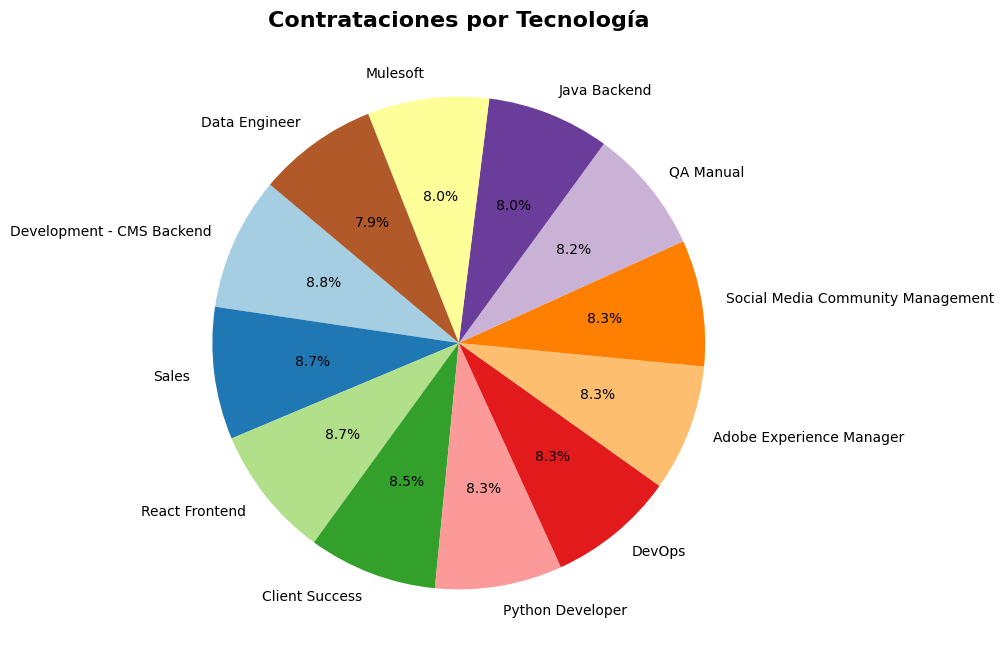

In [ ]:
# Importo la librería estándar para hacer gráficos
import matplotlib.pyplot as plt

#Escribo la consulta SQL
query_tech = """
    SELECT
        t.technology_name,
        COUNT(f.interview_id) AS total_hires
    FROM fact_interviews f
    JOIN dim_technology t ON f.technology_id = t.technology_id
    WHERE f.is_hired = 1
    GROUP BY t.technology_name
    ORDER BY total_hires DESC
"""

#Ejecuto la consulta en el Data Warehouse
df_tech_kpi = pd.read_sql_query(query_tech, conn)

#VERIFICACION DE LOS DATOS EXTRAIDOS
print("Datos extraídos de la BD mediante SQL:")
print(df_tech_kpi)
print("-" * 40)

# Aqui dibujo el grafico de torta
plt.figure(figsize=(10, 8))

# Creacion del grafico
plt.pie(
    df_tech_kpi['total_hires'],
    labels=df_tech_kpi['technology_name'],
    autopct='%1.1f%%', # Muestra el porcentaje con 1 decimal
    startangle=140,    # rotacion del grafico para que se vea bien
    colors=plt.cm.Paired.colors # Se le coloca colores al grafico
)

# Aqui se pone el titulo del grafico
plt.title('Contrataciones por Tecnología', fontsize=16, fontweight='bold')

# Imprime el grafico
plt.show()

ANALISIS Y VISUALIZACION CONTRATACIONES POR AÑO



Datos extraídos de la BD mediante SQL (Por Año):
   year  total_hires
0  2026          187
1  2025         1336
2  2024         1295
3  2023         1336
4  2022         1351
5  2021         1094
----------------------------------------


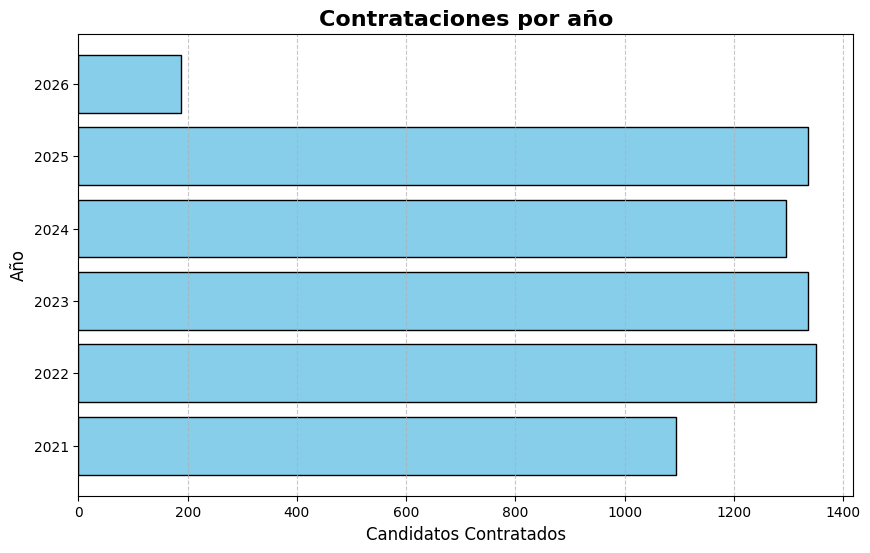

In [ ]:
# Escribo la consulta SQL para agrupar por año
query_year = """
    SELECT
        d.year,
        COUNT(f.interview_id) AS total_hires
    FROM fact_interviews f
    JOIN dim_date d ON f.date_id = d.date_id
    WHERE f.is_hired = 1
    GROUP BY d.year
    ORDER BY d.year DESC
"""

# Ejecuto la consulta en el Data Warehouse
df_year_kpi = pd.read_sql_query(query_year, conn)

# Me aseguro que el año se trate como texto para el gráfico para que no salga con decimales
df_year_kpi['year'] = df_year_kpi['year'].astype(str)

# VERIFICACION DE LOS DATOS EXTRAIDOS
print("Datos extraídos de la BD mediante SQL (Por Año):")
print(df_year_kpi)
print("-" * 40)

# Dibujo el grafico de barras horizontal
plt.figure(figsize=(10, 6))

plt.barh(df_year_kpi['year'], df_year_kpi['total_hires'], color='skyblue', edgecolor='black')

# Aqui se le añaden los titulos y las etiquetas
plt.title('Contrataciones por año', fontsize=16, fontweight='bold')
plt.xlabel('Candidatos Contratados', fontsize=12)
plt.ylabel('Año', fontsize=12)

# Se invierte el eje para que el año mas reciente salga arriba
plt.gca().invert_yaxis()

# Esta linea añade una cuadricula atras del grafico
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Imprime el grafico
plt.show()

ANALISIS Y VISUALIZACION CONTRATACIONES POR SENIORITY

Datos extraídos de la BD mediante SQL (Por Seniority):
  seniority_level  total_hires
0          Senior          927
1          Intern          921
2       Mid-Level          919
3         Manager          897
4            Lead          884
5          Junior          881
6         Trainee          846
7     Desconocido          324
----------------------------------------


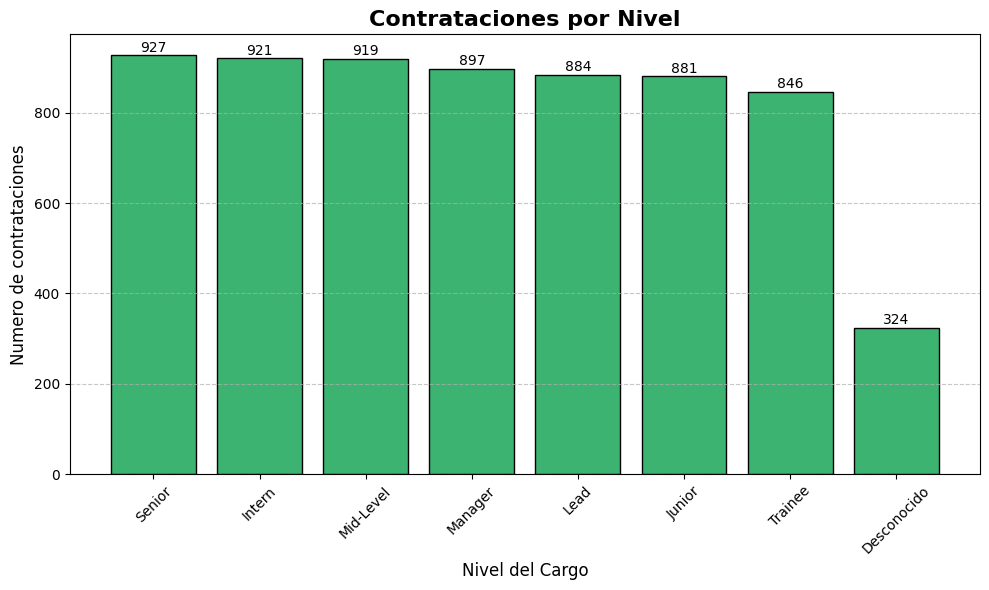

In [ ]:
# Escribo la consulta SQL
query_seniority = """
    SELECT
        s.seniority_level,
        COUNT(f.interview_id) AS total_hires
    FROM fact_interviews f
    JOIN dim_seniority s ON f.seniority_id = s.seniority_id
    WHERE f.is_hired = 1
    GROUP BY s.seniority_level
    ORDER BY total_hires DESC
"""

# Se ejecuta la consulta en el Data Warehouse
df_seniority_kpi = pd.read_sql_query(query_seniority, conn)

#VERIFICACION DE LOS DATOS EXTRAIDOS
print("Datos extraídos de la BD mediante SQL (Por Seniority):")
print(df_seniority_kpi)
print("-" * 40)

# Se crea el grafico de barras vertical
plt.figure(figsize=(10, 6))

# Aqui se forma el grafico
barras = plt.bar(
    df_seniority_kpi['seniority_level'],
    df_seniority_kpi['total_hires'],
    color='mediumseagreen',
    edgecolor='black'
)

# titulos y etiquetas
plt.title('Contrataciones por Nivel', fontsize=16, fontweight='bold')
plt.xlabel('Nivel del Cargo', fontsize=12)
plt.ylabel('Numero de contrataciones', fontsize=12)

plt.xticks(rotation=45)

# Aqui se añade el numero en la parte superior de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=10)

# Se añade la cuadricula del fondo
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Se hace un ajuste para que no se corten las etiquetas
plt.tight_layout()

# Se imprime el grafico
plt.show()

ANALISIS Y VISUALIZACION DE CONTRATACIONES POR PAIS

Datos en formato SQL (Filas):
   year country_name  total_hires
0  2021       Brazil           93
1  2021     Colombia           81
2  2021      Ecuador           76
3  2021          USA           85
4  2022       Brazil           96
5  2022     Colombia          101
6  2022      Ecuador          121
7  2022          USA           91
----------------------------------------
Datos en formato Pivot (Listos para graficar):
country_name  Brazil  Colombia  Ecuador  USA
year                                        
2021              93        81       76   85
2022              96       101      121   91
2023             105       108       98  100
2024              95       102       78  110
2025             107       109      108  108
2026              14        11       18   14
----------------------------------------


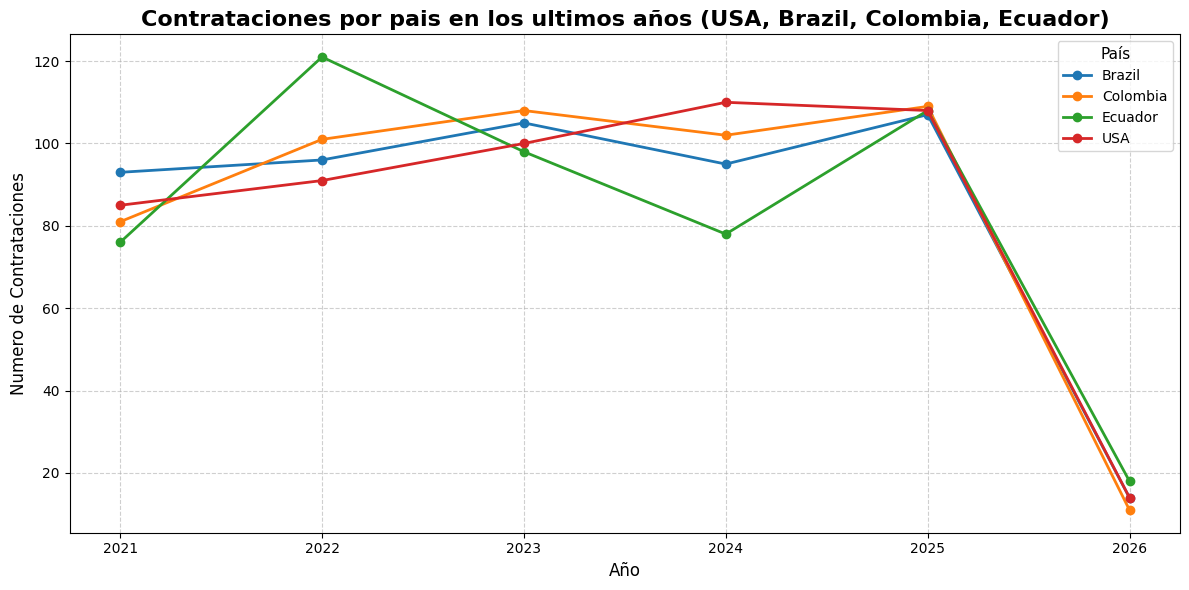

In [ ]:
# Se escribe la consulta SQL con doble JOIN y filtro de paises
query_multiline = """
    SELECT
        d.year,
        c.country_name,
        COUNT(f.interview_id) AS total_hires
    FROM fact_interviews f
    JOIN dim_date d ON f.date_id = d.date_id
    JOIN dim_country c ON f.country_id = c.country_id
    WHERE f.is_hired = 1
      AND c.country_name IN ('USA', 'United States of America', 'United States', 'Brazil', 'Colombia', 'Ecuador')
    GROUP BY d.year, c.country_name
    ORDER BY d.year ASC
"""

# Se ejecuta la consulta
df_multiline_kpi = pd.read_sql_query(query_multiline, conn)

# Se asegura que el año sea un texto para el eje x
df_multiline_kpi['year'] = df_multiline_kpi['year'].astype(int).astype(str)

# VERIFICACION DE DATOS
print("Datos en formato SQL (Filas):")
print(df_multiline_kpi.head(8))
print("-" * 40)

# Aqui se hace la transformacion a tabla dinamica
# Los años en las filas y los paises como columnas
df_pivot = df_multiline_kpi.pivot(index='year', columns='country_name', values='total_hires')

# Si un país no tuvo contratados en un año específico, se rellena el nulo con 0
df_pivot = df_pivot.fillna(0)

print("Datos en formato Pivot (Listos para graficar):")
print(df_pivot)
print("-" * 40)

# Se hace la grafica multilnea
plt.figure(figsize=(12, 6))

# Se dibuja cada linea segun sus criterios
for pais in df_pivot.columns:
    plt.plot(
        df_pivot.index,        # Eje X: Los años
        df_pivot[pais],        # Eje Y: Cantidad de contratados
        marker='o',            # Pone un puntito en cada cruce de año
        linewidth=2,           # Grosor de la línea
        label=pais             # Etiqueta para la leyenda
    )

# titulos, etiquetas y diseño
plt.title('Contrataciones por pais en los ultimos años (USA, Brazil, Colombia, Ecuador)', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Numero de Contrataciones', fontsize=12)

plt.legend(title='País', title_fontsize='11', fontsize='10')

# Se añade la cuadricula
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Imprimimos el grafico
plt.show()